# Stochastic Gradient Descent for Training Deep Neural Networks
## An Interactive Lesson

**MAT 4953 / MAT 6973 — Mathematical Foundations of AI** (Spring 2026, UTSA)

---

In this notebook we explore the mathematical mechanics of **gradient descent** and its stochastic variants, the workhorses behind training deep neural networks. We begin with simple, visualizable functions to build geometric intuition, then progressively introduce the key ideas:

1. **Gradient Descent (GD)** on toy 1-D and 2-D loss surfaces.
2. **Stochastic Gradient Descent (SGD)** — why noise from random mini-batches *helps*.
3. **Momentum** — using a velocity analogy to accelerate convergence.
4. **Adam** — adaptive per-parameter learning rates.
5. **Putting it all together** — training a real neural network on MNIST with Keras/JAX and comparing optimizers head-to-head.

---
# 0. Setup

**Local version** — this notebook is configured to run in a local Jupyter environment on macOS (Apple Silicon). It assumes JAX and Keras are already installed in the active Python virtual environment. See the repository's `requirements.txt`.

For the Google Colab version of this notebook (which installs packages and uses TPU acceleration), see `sgd_interactive_lesson_Colab.ipynb`.

In [20]:
# Local setup — no pip installs needed; packages come from the venv.
# On Apple Silicon (M1/M2/M3/M4), JAX defaults to CPU.
# If you have jax-metal installed, JAX will use the Metal GPU backend automatically.
# NOTE: jax-metal 0.1.1 requires jax/jaxlib <=0.4.38. If you see
#   "UNIMPLEMENTED: default_memory_space is not supported", downgrade:
#     pip install 'jax==0.4.38' 'jaxlib==0.4.38'
#   Or set JAX_PLATFORMS=cpu below to fall back to CPU.
import os
# Uncomment the next line to force CPU if Metal causes issues:
# os.environ["JAX_PLATFORMS"] = "cpu"

import jax
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.4.38
JAX devices: [METAL(id=0)]


In [21]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from IPython.display import display, HTML

import keras
from keras import layers, ops

%matplotlib inline

# Reproducibility
np.random.seed(42)

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}")

Keras version: 3.13.2
Keras backend: jax


---
# 1. Gradient Descent — The Core Idea

## 1.1 The optimization problem

Training a neural network means finding parameters (weights and biases) $\mathbf{w} \in \mathbb{R}^d$ that minimize a **loss function**

$$ℒ(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N} \ell\bigl(f(\mathbf{x}_i; \mathbf{w}),\, y_i\bigr),$$

where $(\mathbf{x}_i, y_i)$ are the training examples, $f(\cdot\,; \mathbf{w})$ is the network, and $\ell$ is a per-sample loss (e.g., cross-entropy).

**Gradient descent** is the iterative algorithm

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \,\nabla ℒ(\mathbf{w}_t),$$

where $\eta > 0$ is the **learning rate**. The negative gradient $-\nabla ℒ$ points in the direction of steepest decrease, so each step reduces the loss (at least for small enough $\eta$).

Let's see this in action on a simple 1-D function.

## 1.2 Gradient descent in one dimension

Consider the function $f(w) = w^4 - 3w^2 + w + 2$. Its derivative is $f'(w) = 4w^3 - 6w + 1$. We will watch gradient descent travel downhill from a starting point.

In [22]:
def f_1d(w):
    """A simple non-convex 1-D function."""
    return w**4 - 3*w**2 + w + 2

def grad_f_1d(w):
    """Derivative of f_1d."""
    return 4*w**3 - 6*w + 1


def gradient_descent_1d(w0, lr, n_steps, grad_fn):
    """Run gradient descent and record the trajectory."""
    trajectory = [w0]
    w = w0
    for _ in range(n_steps):
        w = w - lr * grad_fn(w)
        trajectory.append(w)
    return np.array(trajectory)

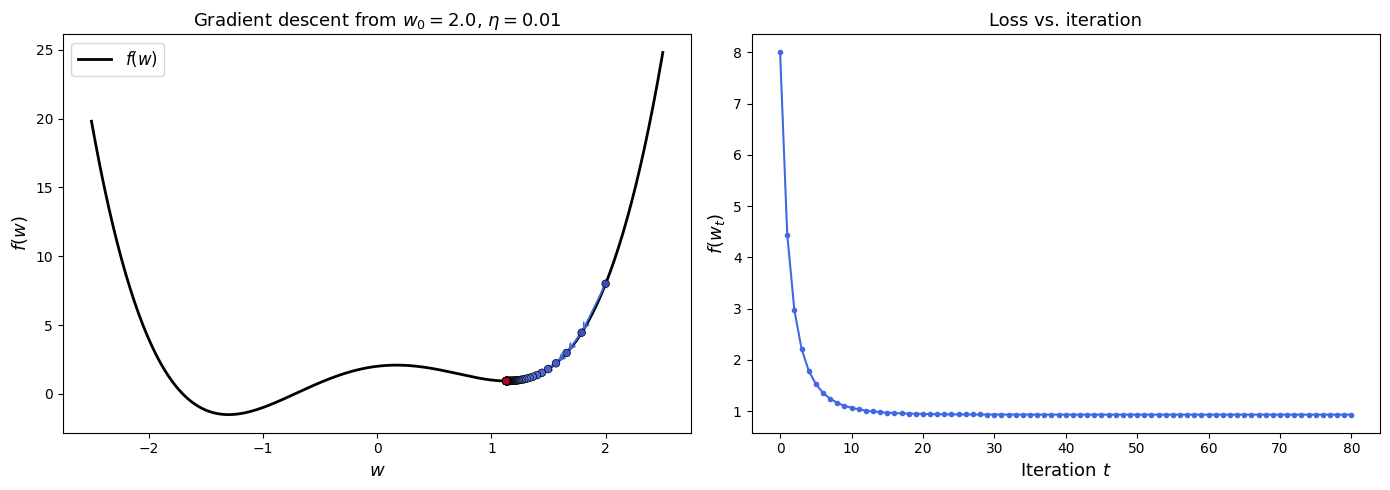

Final w = 1.131030, f(w) = 0.929770


In [23]:
w0 = 2.0        # @param {type: "number"}
lr = 0.01        # @param {type: "number"}
n_steps = 80     # @param {type: "integer"}

trajectory = gradient_descent_1d(w0, lr, n_steps, grad_f_1d)

# --- Plot ---
ws = np.linspace(-2.5, 2.5, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: function with trajectory
ax = axes[0]
ax.plot(ws, f_1d(ws), 'k-', lw=2, label=r'$f(w)$')
ax.scatter(trajectory, f_1d(trajectory), c=np.arange(len(trajectory)),
           cmap='coolwarm', s=30, zorder=5, edgecolors='k', linewidths=0.5)
# Draw arrows between consecutive points
for i in range(len(trajectory) - 1):
    ax.annotate('', xy=(trajectory[i+1], f_1d(trajectory[i+1])),
                xytext=(trajectory[i], f_1d(trajectory[i])),
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.2))
ax.set_xlabel('$w$', fontsize=13)
ax.set_ylabel('$f(w)$', fontsize=13)
ax.set_title(f'Gradient descent from $w_0={w0}$, $\\eta={lr}$', fontsize=13)
ax.legend(fontsize=12)

# Right: loss over iterations
ax = axes[1]
ax.plot(f_1d(trajectory), 'o-', ms=3, color='royalblue')
ax.set_xlabel('Iteration $t$', fontsize=13)
ax.set_ylabel('$f(w_t)$', fontsize=13)
ax.set_title('Loss vs. iteration', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Final w = {trajectory[-1]:.6f}, f(w) = {f_1d(trajectory[-1]):.6f}")

**Experiment:** Try changing `w0`, `lr`, and `n_steps` above.

- What happens with a *very large* learning rate (e.g., $\eta = 0.1$)?
- What happens if you start at $w_0 = -0.1$ instead of $w_0 = 2.0$? Does GD find the same minimum?

This illustrates two important phenomena:
1. The learning rate must be chosen carefully — too large and GD *diverges*.
2. GD converges to a **local** minimum, which depends on the starting point. For non-convex loss surfaces (which arise in deep learning), there may be many local minima.

## 1.3 Gradient descent in two dimensions

Now consider a 2-D function $f(w_1, w_2) = w_1^2 + 5\,w_2^2 + 2\,w_1\,w_2 - 4\,w_1$. This has an elliptical landscape — the eigenvalues of its Hessian differ substantially, making the contours elongated. This is a common situation in neural network loss surfaces and illustrates why vanilla GD can be slow.

In [24]:
def f_2d(w):
    """Quadratic 2-D function with ill-conditioning."""
    w1, w2 = w
    return w1**2 + 5*w2**2 + 2*w1*w2 - 4*w1

def grad_f_2d(w):
    """Gradient of f_2d."""
    w1, w2 = w
    return np.array([2*w1 + 2*w2 - 4, 10*w2 + 2*w1])


def gradient_descent_2d(w0, lr, n_steps, grad_fn):
    """Run GD in 2-D and record the trajectory."""
    w = np.array(w0, dtype=float)
    trajectory = [w.copy()]
    for _ in range(n_steps):
        w = w - lr * grad_fn(w)
        trajectory.append(w.copy())
    return np.array(trajectory)

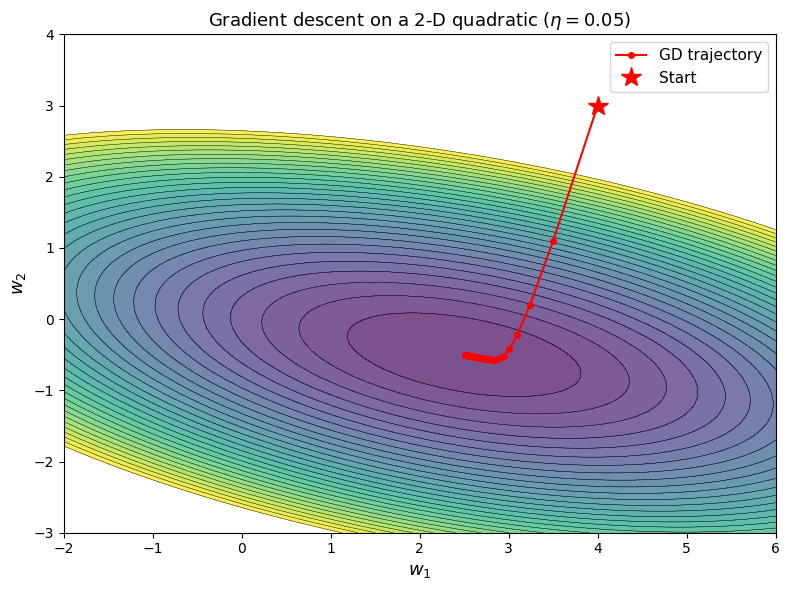

Final w = (2.5120, -0.5028), f(w) = -4.999884


In [25]:
w0_2d = [4.0, 3.0]   # Starting point
lr_2d = 0.05          # @param {type: "number"}
n_steps_2d = 50       # @param {type: "integer"}

traj_2d = gradient_descent_2d(w0_2d, lr_2d, n_steps_2d, grad_f_2d)

# --- Contour plot ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
w1_grid = np.linspace(-2, 6, 300)
w2_grid = np.linspace(-3, 4, 300)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = f_2d([W1, W2])

levels = np.linspace(Z.min(), Z.min() + 40, 30)
ax.contourf(W1, W2, Z, levels=levels, cmap='viridis', alpha=0.7)
ax.contour(W1, W2, Z, levels=levels, colors='k', linewidths=0.3)

# Plot trajectory
ax.plot(traj_2d[:, 0], traj_2d[:, 1], 'o-', color='red', ms=4, lw=1.5,
        label='GD trajectory', zorder=5)
ax.plot(traj_2d[0, 0], traj_2d[0, 1], 'r*', ms=15, zorder=6, label='Start')
ax.set_xlabel('$w_1$', fontsize=13)
ax.set_ylabel('$w_2$', fontsize=13)
ax.set_title(f'Gradient descent on a 2-D quadratic ($\\eta={lr_2d}$)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Final w = ({traj_2d[-1, 0]:.4f}, {traj_2d[-1, 1]:.4f}), "
      f"f(w) = {f_2d(traj_2d[-1]):.6f}")

Notice the characteristic **zig-zag** pattern: the gradient points roughly perpendicular to the long axis of the ellipse, so the iterates oscillate across the narrow direction while making slow progress along the long direction. This is directly related to the **condition number** of the Hessian $\nabla^2 f$ (the ratio of its largest to smallest eigenvalue). When the condition number is large, GD converges slowly.

This motivates the improvements we will study next.

---
# 2. From Full-Batch GD to Stochastic Gradient Descent

## 2.1 The computational bottleneck

Recall the full loss:

$$ℒ(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N} \ell_i(\mathbf{w}).$$

Computing $\nabla ℒ(\mathbf{w})$ requires summing over *all* $N$ training examples. For ImageNet ($N \approx 1.2$ million) or large language models ($N \sim$ billions of tokens), this is prohibitively expensive per step.

## 2.2 The stochastic approximation

**Stochastic gradient descent** (SGD) replaces the full gradient with a *noisy estimate* computed from a random **mini-batch** $\mathcal{B} \subset \{1, \ldots, N\}$ of size $|\mathcal{B}| = B$:

$$\mathbf{g}_t = \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla \ell_i(\mathbf{w}_t).$$

The key mathematical property is that $\mathbf{g}_t$ is an **unbiased estimator** of the true gradient:

$$\mathbb{E}_{\mathcal{B}_t}[\mathbf{g}_t] = \nabla ℒ(\mathbf{w}_t).$$

The variance of this estimator scales as $\mathrm{Var}(\mathbf{g}_t) \propto 1/B$: larger batches give more accurate gradient estimates but are more expensive.

The SGD update is then:

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta\, \mathbf{g}_t.$$

Let's simulate this to see the effect of mini-batch noise.

## 2.3 Simulating SGD vs. full-batch GD

We'll create a synthetic regression problem: $N$ data points $(x_i, y_i)$ drawn from a noisy linear model $y = 2x + 1 + \varepsilon$, and optimize the **mean squared error**

$$ℒ(w, b) = \frac{1}{N}\sum_{i=1}^{N}(w\,x_i + b - y_i)^2$$

using both full-batch GD and SGD with varying batch sizes.

In [26]:
# Generate synthetic data: y = 2x + 1 + noise
N = 500
x_data = np.random.randn(N)
y_data = 2 * x_data + 1 + 0.5 * np.random.randn(N)


def mse_loss(w, b, x, y):
    """Mean squared error."""
    return np.mean((w * x + b - y)**2)


def mse_grad(w, b, x, y):
    """Gradient of MSE with respect to (w, b)."""
    residuals = w * x + b - y
    dw = 2 * np.mean(residuals * x)
    db = 2 * np.mean(residuals)
    return np.array([dw, db])


def run_sgd(x_data, y_data, w0, b0, lr, n_epochs, batch_size):
    """
    Run SGD (or full-batch GD when batch_size == len(x_data)).
    Returns trajectories of (w, b) and loss.
    """
    N = len(x_data)
    w, b = w0, b0
    params_history = [(w, b)]
    loss_history = [mse_loss(w, b, x_data, y_data)]

    for epoch in range(n_epochs):
        # Shuffle data each epoch
        perm = np.random.permutation(N)
        x_shuffled = x_data[perm]
        y_shuffled = y_data[perm]

        for start in range(0, N, batch_size):
            x_batch = x_shuffled[start:start+batch_size]
            y_batch = y_shuffled[start:start+batch_size]
            grad = mse_grad(w, b, x_batch, y_batch)
            w -= lr * grad[0]
            b -= lr * grad[1]
            params_history.append((w, b))
            loss_history.append(mse_loss(w, b, x_data, y_data))

    return np.array(params_history), np.array(loss_history)

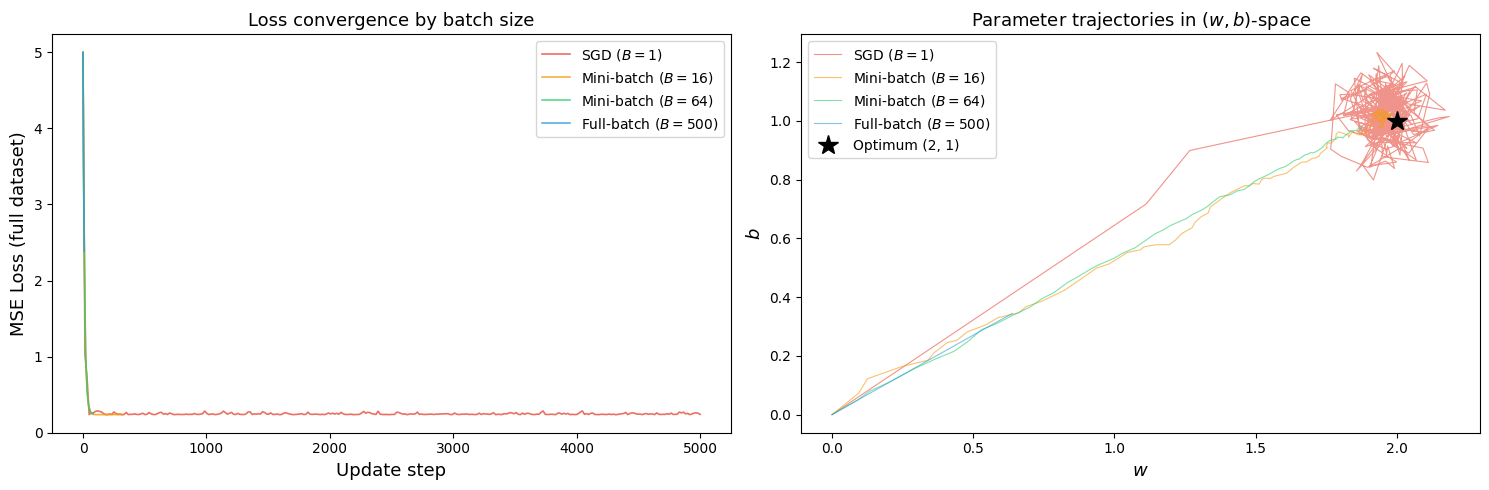

In [27]:
n_epochs = 10  # @param {type: "integer"}

# Initial parameters (same for all runs)
w0, b0 = 0.0, 0.0
lr_sgd = 0.02

# Run with different batch sizes
batch_sizes = [1, 16, 64, N]  # SGD, mini-batch, mini-batch, full-batch
labels = ['SGD ($B=1$)', 'Mini-batch ($B=16$)', 'Mini-batch ($B=64$)', f'Full-batch ($B={N}$)']
colors_list = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for bs, label, color in zip(batch_sizes, labels, colors_list):
    np.random.seed(42)  # Same shuffling for fair comparison
    params, losses = run_sgd(x_data, y_data, w0, b0, lr_sgd, n_epochs, bs)

    # Subsample for clarity if too many steps
    max_pts = 300
    if len(losses) > max_pts:
        idx = np.linspace(0, len(losses)-1, max_pts, dtype=int)
    else:
        idx = np.arange(len(losses))

    axes[0].plot(idx, losses[idx], color=color, alpha=0.8, label=label, lw=1.2)
    axes[1].plot(params[idx, 0], params[idx, 1], color=color, alpha=0.6, lw=0.8, label=label)

# Optimal point
axes[1].plot(2, 1, 'k*', ms=15, zorder=10, label='Optimum (2, 1)')

axes[0].set_xlabel('Update step', fontsize=13)
axes[0].set_ylabel('MSE Loss (full dataset)', fontsize=13)
axes[0].set_title('Loss convergence by batch size', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(bottom=0)

axes[1].set_xlabel('$w$', fontsize=13)
axes[1].set_ylabel('$b$', fontsize=13)
axes[1].set_title('Parameter trajectories in $(w, b)$-space', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

**Observations:**

- **Full-batch GD** ($B = N$) follows a smooth, deterministic path directly toward the minimum.
- **Pure SGD** ($B = 1$) is extremely noisy — the gradient estimate from a single sample has high variance. The trajectory jitters wildly but still trends toward the optimum on average.
- **Mini-batch SGD** ($B = 16$ or $64$) strikes a balance: each step is fast (processing far fewer samples than full-batch) while the gradient estimate is accurate enough for reliable progress.

In practice, mini-batch sizes of 32–512 are common. The noise in SGD is not purely a nuisance — it acts as a form of **implicit regularization** that can help the optimizer escape sharp local minima and find flatter, more generalizable solutions.

## 2.4 Convergence theory (brief sketch)

For **convex** losses with Lipschitz-continuous gradients (constant $L$), full-batch GD with step size $\eta \le 1/L$ satisfies

$$ℒ(\mathbf{w}_T) - ℒ(\mathbf{w}^*) \le \frac{\|\mathbf{w}_0 - \mathbf{w}^*\|^2}{2\,\eta\,T}.$$

This is an $O(1/T)$ rate. For SGD with bounded variance $\sigma^2 = \mathrm{Var}(\mathbf{g}_t)$ and a decaying learning rate $\eta_t \propto 1/\sqrt{t}$, one obtains

$$\mathbb{E}[ℒ(\bar{\mathbf{w}}_T)] - ℒ(\mathbf{w}^*) = O\!\left(\frac{1}{\sqrt{T}}\right),$$

where $\bar{\mathbf{w}}_T$ is an appropriate average of the iterates. The slower rate is the price paid for using noisy gradients.

For **non-convex** losses (the typical case in deep learning), convergence guarantees are weaker — one can show that $\|\nabla ℒ(\mathbf{w}_t)\| \to 0$, meaning SGD finds a *stationary point* (which might be a local minimum or a saddle point), but global optimality is not guaranteed.

---
# 3. SGD with Momentum

## 3.1 The physical analogy

Imagine a heavy ball rolling down the loss surface. It accumulates velocity as it rolls downhill, and its inertia carries it through shallow regions and across small bumps. This is the idea behind **momentum**.

The update rule introduces a **velocity** variable $\mathbf{v}_t$:

$$\begin{aligned}
\mathbf{v}_{t+1} &= \beta\, \mathbf{v}_t + \nabla ℒ(\mathbf{w}_t), \\
\mathbf{w}_{t+1} &= \mathbf{w}_t - \eta\, \mathbf{v}_{t+1},
\end{aligned}$$

where $\beta \in [0, 1)$ is the momentum coefficient (typically $\beta = 0.9$). The velocity $\mathbf{v}_t$ is an **exponential moving average** of past gradients. This has two benefits:

1. **Acceleration along consistent directions:** When the gradient consistently points the same way, velocity builds up, speeding convergence.
2. **Damping of oscillations:** When the gradient alternates direction (as in the zig-zag pattern above), the averaging cancels out the oscillations.

Let's see this on our 2-D quadratic.

In [28]:
def gd_momentum_2d(w0, lr, beta, n_steps, grad_fn):
    """Gradient descent with momentum in 2-D."""
    w = np.array(w0, dtype=float)
    v = np.zeros_like(w)
    trajectory = [w.copy()]
    for _ in range(n_steps):
        g = grad_fn(w)
        v = beta * v + g
        w = w - lr * v
        trajectory.append(w.copy())
    return np.array(trajectory)

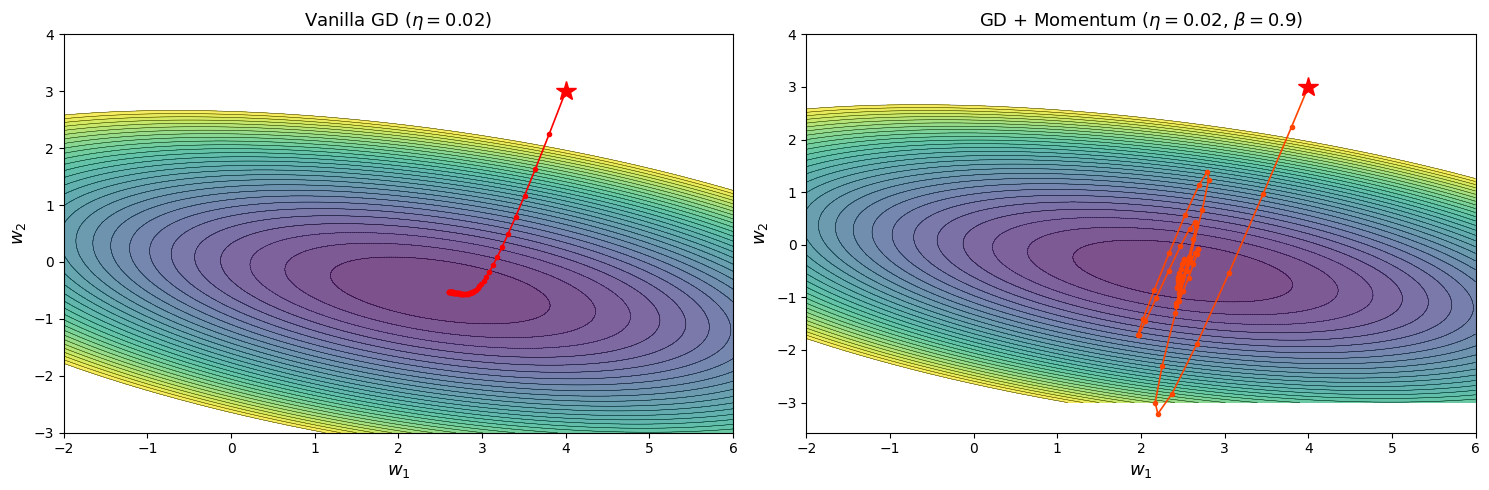

Vanilla GD final loss:  -4.992072
Momentum  final loss:   -4.867253


In [29]:
beta_mom = 0.9       # @param {type: "number"}
lr_compare = 0.02    # @param {type: "number"}
n_steps_cmp = 60     # @param {type: "integer"}
w0_cmp = [4.0, 3.0]

traj_gd = gradient_descent_2d(w0_cmp, lr_compare, n_steps_cmp, grad_f_2d)
traj_mom = gd_momentum_2d(w0_cmp, lr_compare, beta_mom, n_steps_cmp, grad_f_2d)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax in axes:
    ax.contourf(W1, W2, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.contour(W1, W2, Z, levels=levels, colors='k', linewidths=0.3)

# Left: vanilla GD
axes[0].plot(traj_gd[:, 0], traj_gd[:, 1], 'o-', color='red', ms=3, lw=1.2)
axes[0].plot(traj_gd[0, 0], traj_gd[0, 1], 'r*', ms=15)
axes[0].set_title(f'Vanilla GD ($\\eta={lr_compare}$)', fontsize=13)
axes[0].set_xlabel('$w_1$', fontsize=13)
axes[0].set_ylabel('$w_2$', fontsize=13)

# Right: GD with momentum
axes[1].plot(traj_mom[:, 0], traj_mom[:, 1], 'o-', color='orangered', ms=3, lw=1.2)
axes[1].plot(traj_mom[0, 0], traj_mom[0, 1], 'r*', ms=15)
axes[1].set_title(f'GD + Momentum ($\\eta={lr_compare}$, $\\beta={beta_mom}$)', fontsize=13)
axes[1].set_xlabel('$w_1$', fontsize=13)
axes[1].set_ylabel('$w_2$', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Vanilla GD final loss:  {f_2d(traj_gd[-1]):.6f}")
print(f"Momentum  final loss:   {f_2d(traj_mom[-1]):.6f}")

Momentum dramatically reduces the zig-zag oscillations and converges much faster to the minimum. The velocity variable smooths out the oscillations in the narrow direction while accumulating speed in the consistent direction.

---
# 4. Adam — Adaptive Moment Estimation

## 4.1 The idea

**Adam** (Kingma & Ba, 2015) combines two ideas:

1. **Momentum** (first moment): It keeps an exponential moving average of the gradient.
2. **RMSProp** (second moment): It keeps an exponential moving average of the *squared* gradient, giving each parameter its own adaptive learning rate.

The full update at step $t$ is:

$$\begin{aligned}
\mathbf{m}_t &= \beta_1\, \mathbf{m}_{t-1} + (1 - \beta_1)\, \mathbf{g}_t, &\quad &\text{(first moment estimate)}\\
\mathbf{v}_t &= \beta_2\, \mathbf{v}_{t-1} + (1 - \beta_2)\, \mathbf{g}_t^2, &\quad &\text{(second moment estimate)}\\
\hat{\mathbf{m}}_t &= \frac{\mathbf{m}_t}{1 - \beta_1^t}, &\quad &\text{(bias correction)}\\
\hat{\mathbf{v}}_t &= \frac{\mathbf{v}_t}{1 - \beta_2^t}, &\quad &\text{(bias correction)}\\
\mathbf{w}_{t+1} &= \mathbf{w}_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon}. &\quad &
\end{aligned}$$

Typical defaults: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$.

**Why bias correction?** Since $\mathbf{m}_0 = \mathbf{v}_0 = 0$, the early estimates are biased toward zero. The correction terms $1/(1-\beta^t)$ compensate for this initialization bias.

**Why the division by $\sqrt{\hat{\mathbf{v}}_t}$?** Parameters whose gradients are consistently large get *smaller* effective learning rates, and vice versa. This naturally adapts the step size per coordinate — very helpful when different parameters operate on different scales, as is typical in deep networks.

In [30]:
def adam_2d(w0, lr, beta1, beta2, eps, n_steps, grad_fn):
    """Adam optimizer in 2-D."""
    w = np.array(w0, dtype=float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    trajectory = [w.copy()]
    for t in range(1, n_steps + 1):
        g = grad_fn(w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        trajectory.append(w.copy())
    return np.array(trajectory)

## 4.2 Head-to-head comparison on the 2-D surface

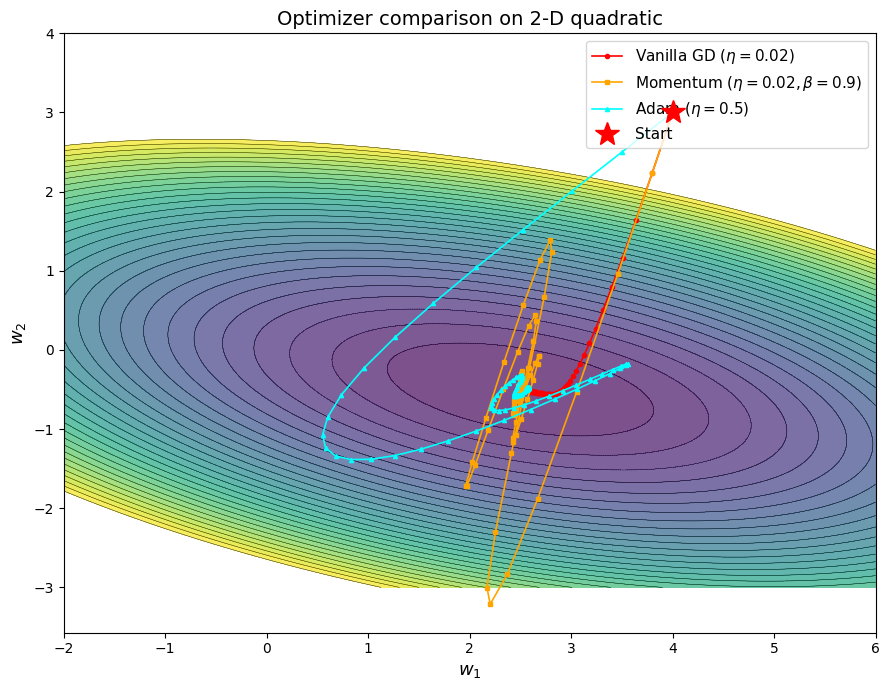

Vanilla GD final loss:  -4.997709
Momentum  final loss:   -4.983884
Adam      final loss:   -4.992178


In [31]:
lr_adam = 0.5          # @param {type: "number"}
n_steps_all = 80       # @param {type: "integer"}

traj_gd_c   = gradient_descent_2d(w0_cmp, 0.02, n_steps_all, grad_f_2d)
traj_mom_c  = gd_momentum_2d(w0_cmp, 0.02, 0.9, n_steps_all, grad_f_2d)
traj_adam_c  = adam_2d(w0_cmp, lr_adam, 0.9, 0.999, 1e-8, n_steps_all, grad_f_2d)

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.contourf(W1, W2, Z, levels=levels, cmap='viridis', alpha=0.7)
ax.contour(W1, W2, Z, levels=levels, colors='k', linewidths=0.3)

ax.plot(traj_gd_c[:, 0], traj_gd_c[:, 1], 'o-', color='red', ms=3, lw=1.2,
        label=f'Vanilla GD ($\\eta=0.02$)')
ax.plot(traj_mom_c[:, 0], traj_mom_c[:, 1], 's-', color='orange', ms=3, lw=1.2,
        label=f'Momentum ($\\eta=0.02, \\beta=0.9$)')
ax.plot(traj_adam_c[:, 0], traj_adam_c[:, 1], '^-', color='cyan', ms=3, lw=1.2,
        label=f'Adam ($\\eta={lr_adam}$)')
ax.plot(w0_cmp[0], w0_cmp[1], 'r*', ms=18, zorder=10, label='Start')

ax.set_xlabel('$w_1$', fontsize=13)
ax.set_ylabel('$w_2$', fontsize=13)
ax.set_title('Optimizer comparison on 2-D quadratic', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Vanilla GD final loss:  {f_2d(traj_gd_c[-1]):.6f}")
print(f"Momentum  final loss:   {f_2d(traj_mom_c[-1]):.6f}")
print(f"Adam      final loss:   {f_2d(traj_adam_c[-1]):.6f}")

## 4.3 Comparing convergence on the synthetic regression problem

Let's also compare the three optimizers on the linear regression problem from Section 2, using mini-batches.

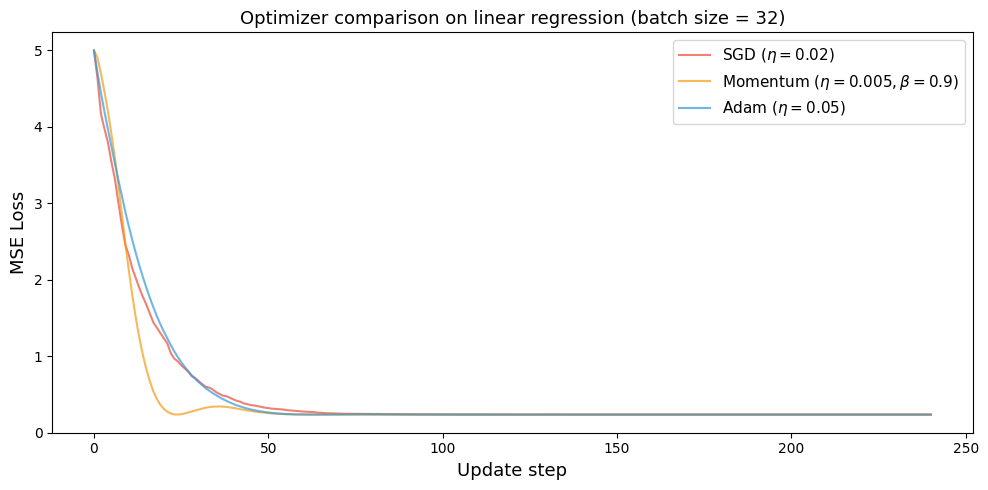

In [32]:
def run_optimizer(x_data, y_data, w0, b0, lr, n_epochs, batch_size,
                  optimizer='sgd', beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Generic mini-batch optimizer: 'sgd', 'momentum', or 'adam'.
    Returns loss history (evaluated on full dataset after each update).
    """
    N_data = len(x_data)
    w, b = w0, b0
    loss_history = [mse_loss(w, b, x_data, y_data)]

    # State variables
    v_w, v_b = 0.0, 0.0      # velocity (momentum) / second moment (adam)
    m_w, m_b = 0.0, 0.0      # first moment (adam)
    s_w, s_b = 0.0, 0.0      # second moment (adam)
    t = 0

    for epoch in range(n_epochs):
        perm = np.random.permutation(N_data)
        x_s, y_s = x_data[perm], y_data[perm]

        for start in range(0, N_data, batch_size):
            t += 1
            xb = x_s[start:start+batch_size]
            yb = y_s[start:start+batch_size]
            grad = mse_grad(w, b, xb, yb)
            gw, gb = grad[0], grad[1]

            if optimizer == 'sgd':
                w -= lr * gw
                b -= lr * gb
            elif optimizer == 'momentum':
                v_w = beta1 * v_w + gw
                v_b = beta1 * v_b + gb
                w -= lr * v_w
                b -= lr * v_b
            elif optimizer == 'adam':
                m_w = beta1 * m_w + (1 - beta1) * gw
                m_b = beta1 * m_b + (1 - beta1) * gb
                s_w = beta2 * s_w + (1 - beta2) * gw**2
                s_b = beta2 * s_b + (1 - beta2) * gb**2
                mw_hat = m_w / (1 - beta1**t)
                mb_hat = m_b / (1 - beta1**t)
                sw_hat = s_w / (1 - beta2**t)
                sb_hat = s_b / (1 - beta2**t)
                w -= lr * mw_hat / (np.sqrt(sw_hat) + eps)
                b -= lr * mb_hat / (np.sqrt(sb_hat) + eps)

            loss_history.append(mse_loss(w, b, x_data, y_data))

    return np.array(loss_history)


# Run all three
np.random.seed(42)
batch_sz = 32
n_ep = 15

loss_sgd  = run_optimizer(x_data, y_data, 0., 0., 0.02, n_ep, batch_sz, 'sgd')
np.random.seed(42)
loss_mom  = run_optimizer(x_data, y_data, 0., 0., 0.005, n_ep, batch_sz, 'momentum')
np.random.seed(42)
loss_adam = run_optimizer(x_data, y_data, 0., 0., 0.05, n_ep, batch_sz, 'adam')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_sgd, alpha=0.7, label='SGD ($\\eta=0.02$)', color='#e74c3c')
ax.plot(loss_mom, alpha=0.7, label='Momentum ($\\eta=0.005, \\beta=0.9$)', color='#f39c12')
ax.plot(loss_adam, alpha=0.7, label='Adam ($\\eta=0.05$)', color='#3498db')
ax.set_xlabel('Update step', fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Optimizer comparison on linear regression (batch size = 32)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---
# 5. SGD in Practice — Training a Neural Network on MNIST

We now apply everything we've learned to train a real feedforward neural network on the MNIST handwritten digit dataset, comparing the three optimizers.

## 5.1 Load and preprocess the data

Training set: 60000 images, each of dimension 784
Test set:     10000 images


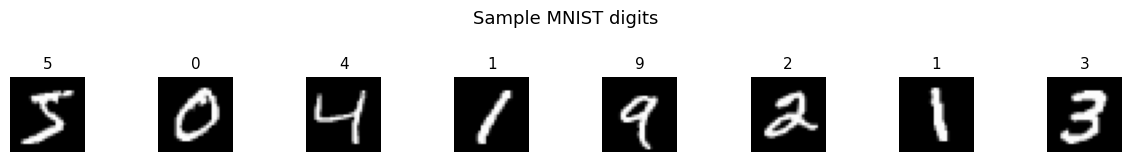

In [33]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Flatten 28x28 images to 784-dimensional vectors and normalize to [0, 1]
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test  = x_test.reshape(10000, 784).astype("float32") / 255

print(f"Training set: {x_train.shape[0]} images, each of dimension {x_train.shape[1]}")
print(f"Test set:     {x_test.shape[0]} images")

# Show some examples
fig, axes = plt.subplots(1, 8, figsize=(12, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=11)
    ax.axis('off')
plt.suptitle('Sample MNIST digits', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## 5.2 Define the model

We use a feedforward network with two hidden layers of 128 units each and ReLU activations, identical architecture for all three optimizer runs.

In [34]:
def build_model():
    """Build a fresh feedforward model for MNIST."""
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10)(x)  # logits
    model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_ff")
    return model

# Show architecture
demo_model = build_model()
demo_model.summary()

Model: "mnist_ff"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5.3 Train with each optimizer

We train three copies of the same architecture (with the same weight initialization) using SGD, SGD + Momentum, and Adam, and compare their training curves.

In [35]:
num_epochs = 15         # @param {type: "integer"}
batch_size = 64         # @param {type: "integer"}
validation_split = 0.2  # @param {type: "number"}

# Define optimizers to compare
optimizer_configs = [
    ('SGD',           keras.optimizers.SGD(learning_rate=0.01)),
    ('SGD + Momentum', keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam',          keras.optimizers.Adam(learning_rate=0.001)),
]

histories = {}

# Get reference initial weights (so all models start identically)
ref_model = build_model()
init_weights = ref_model.get_weights()

for name, opt in optimizer_configs:
    print(f"\n{'='*50}")
    print(f"Training with {name}")
    print(f"{'='*50}")

    model = build_model()
    model.set_weights([w.copy() for w in init_weights])  # Same initialization

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=opt,
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=validation_split,
        verbose=1,
    )

    test_scores = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n{name} — Test loss: {test_scores[0]:.4f}, Test accuracy: {test_scores[1]:.4f}")

    histories[name] = history.history


Training with SGD
Epoch 1/15


/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(int32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


729/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5359 - loss: 1.6014

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7291 - loss: 1.0557 - val_accuracy: 0.8814 - val_loss: 0.4631
Epoch 2/15
127/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8804 - loss: 0.4725

...

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9128 - loss: 0.2997 - val_accuracy: 0.9543 - val_loss: 0.1507
Epoch 2/15
105/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9523 - loss: 0.1586

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9646 - loss: 0.1188 - val_accuracy: 0.9646 - val_loss: 0.1152
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9757 - loss: 0.0795 - val_accuracy: 0.9696 - val_loss: 0.0996
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.9704 - val_loss: 0.1023
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9726 - val_loss: 0.0945
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0361 - val_accuracy: 0.9753 - val_loss: 0.0933
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.0295 - val_accuracy: 0.9735 - val_loss: 0.1005
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9755 - val_loss: 0.1027
Epoch 9/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9924 - loss: 0.0233 - val_accuracy: 0.9757 - val_

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


## 5.4 Visualize training curves

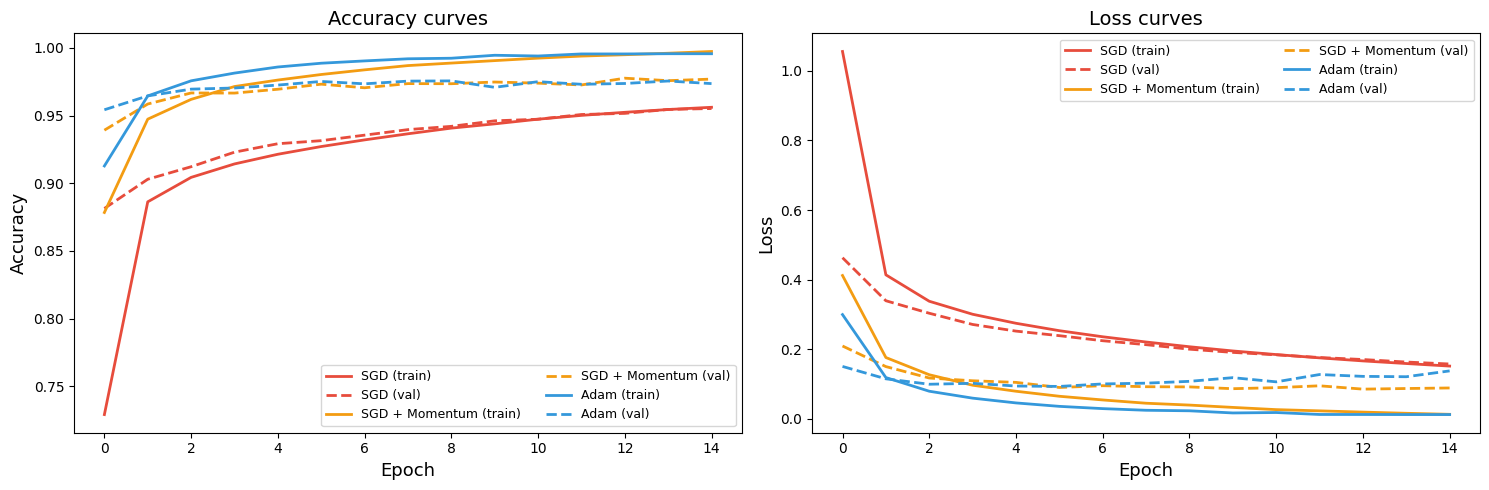

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_opt = {'SGD': '#e74c3c', 'SGD + Momentum': '#f39c12', 'Adam': '#3498db'}

for name, hist in histories.items():
    c = colors_opt[name]
    axes[0].plot(hist['accuracy'], '-', color=c, lw=2, label=f'{name} (train)')
    axes[0].plot(hist['val_accuracy'], '--', color=c, lw=2, label=f'{name} (val)')

    axes[1].plot(hist['loss'], '-', color=c, lw=2, label=f'{name} (train)')
    axes[1].plot(hist['val_loss'], '--', color=c, lw=2, label=f'{name} (val)')

axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy curves', fontsize=14)
axes[0].legend(fontsize=9, ncol=2)

axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Loss', fontsize=13)
axes[1].set_title('Loss curves', fontsize=14)
axes[1].legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

## 5.5 The effect of batch size

An important practical consideration is the choice of **batch size**. Let's fix the optimizer (Adam) and vary the batch size to observe the trade-off between noise and convergence speed.

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(int32[]), ShapedArray(float32[]), ShapedArray(float32[784,128]), ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not us

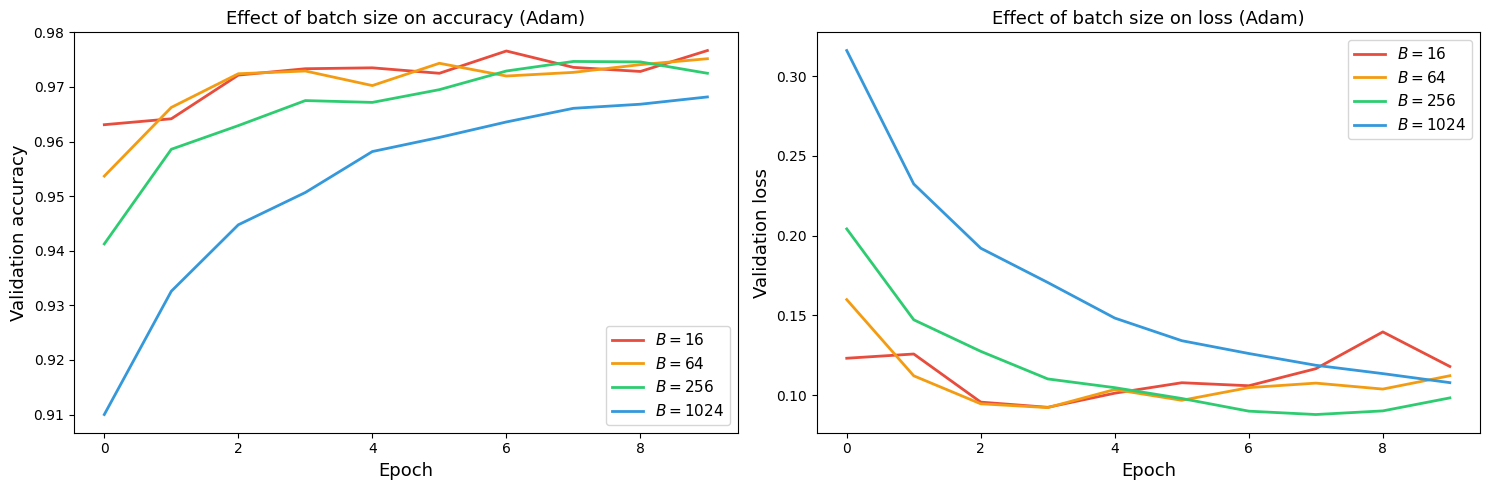

In [37]:
batch_sizes_exp = [16, 64, 256, 1024]  # @param
n_epochs_bs = 10  # @param {type: "integer"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bs_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for bs, color in zip(batch_sizes_exp, bs_colors):
    model = build_model()
    model.set_weights([w.copy() for w in init_weights])
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"],
    )
    hist = model.fit(x_train, y_train, batch_size=bs, epochs=n_epochs_bs,
                     validation_split=0.2, verbose=0)

    axes[0].plot(hist.history['val_accuracy'], '-', color=color, lw=2,
                 label=f'$B={bs}$')
    axes[1].plot(hist.history['val_loss'], '-', color=color, lw=2,
                 label=f'$B={bs}$')

axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Validation accuracy', fontsize=13)
axes[0].set_title('Effect of batch size on accuracy (Adam)', fontsize=13)
axes[0].legend(fontsize=11)

axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Validation loss', fontsize=13)
axes[1].set_title('Effect of batch size on loss (Adam)', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Discussion:**

- Smaller batch sizes introduce more noise per step but execute more parameter updates per epoch, often converging faster *in wall-clock time* for the first few epochs.
- Larger batch sizes give smoother loss curves and more stable training, but each epoch involves fewer parameter updates (all else being equal, each update is more expensive but higher quality).
- The "generalization gap" hypothesis suggests that the noise from smaller batches acts as implicit regularization, sometimes finding solutions that generalize better to unseen data.

## 5.6 Visualizing predictions

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(int32[]), ShapedArray(float32[]), ShapedArray(float32[784,128]), ShapedArray(float32[784,128]), ShapedArray(float32[128]), ShapedArray(float32[128]), ShapedArray(float32[128,128]), ShapedArray(float32[128,128]), ShapedArray(float32[128]), ShapedArray(float32[128]), ShapedArray(float32[128,10]), ShapedArray(float32[128,10]), ShapedArray(float32[10]), ShapedArray(float32[10]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not us

Final model — Test accuracy: 0.9762


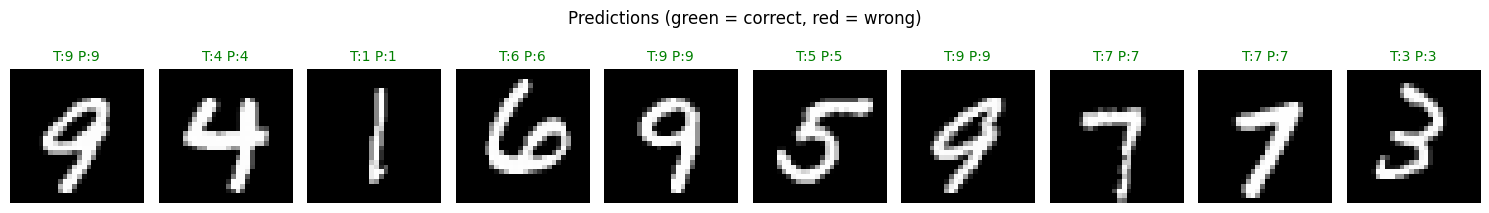

In [38]:
# Re-train a final model with Adam for prediction display
final_model = build_model()
final_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
final_model.fit(x_train, y_train, batch_size=64, epochs=15,
                validation_split=0.2, verbose=0)

test_scores = final_model.evaluate(x_test, y_test, verbose=0)
print(f"Final model — Test accuracy: {test_scores[1]:.4f}")

# Display some predictions
num_samples = 10
indices = np.random.choice(len(x_test), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
for i, idx in enumerate(indices):
    img = x_test[idx].reshape(28, 28)
    pred = final_model.predict(np.expand_dims(x_test[idx], 0), verbose=0)
    pred_label = np.argmax(pred, axis=1)[0]
    true_label = y_test[idx]
    color = 'green' if pred_label == true_label else 'red'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"T:{true_label} P:{pred_label}", fontsize=10, color=color)
    axes[i].axis('off')

plt.suptitle('Predictions (green = correct, red = wrong)', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

---
# 6. Summary

| Optimizer | Update rule | Key property |
|-----------|-------------|--------------|
| **GD** | $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nablaℒ$ | Deterministic, uses all data |
| **SGD** | Same, but $\nablaℒ$ estimated from mini-batch | Cheaper per step, noisy but unbiased |
| **Momentum** | Adds velocity $\mathbf{v} = \beta\mathbf{v} + \mathbf{g}$ | Damps oscillations, accelerates convergence |
| **Adam** | Adaptive LR via first and second moment estimates | Per-parameter adaptation, widely used default |

**Key takeaways:**

1. SGD replaces the expensive full-gradient computation with a cheap, noisy estimate. The unbiasedness of this estimate guarantees convergence (under appropriate learning rate schedules).

2. The noise in SGD is not just a necessary evil — it provides implicit regularization that can improve generalization.

3. Momentum uses an exponential moving average to smooth the trajectory and accelerate convergence, especially on ill-conditioned loss landscapes.

4. Adam combines momentum with per-parameter adaptive learning rates, making it robust across a wide range of architectures and hyperparameter choices. It is the most commonly used optimizer in deep learning.

5. The choice of batch size, learning rate, and optimizer are among the most important *hyperparameters* in deep learning — they are not learned from data but must be set by the practitioner.

---
# 7. Exercises

1. **Learning rate sensitivity.** Return to the 1-D gradient descent example (Section 1.2). Find the largest learning rate $\eta$ for which GD converges starting from $w_0 = 2$. What happens just above this threshold? Explain in terms of the curvature of $f$.

2. **Saddle points.** Define the function $f(w_1, w_2) = w_1^2 - w_2^2$ (a saddle surface). Run vanilla GD, momentum, and Adam starting from $(0.01, 0.01)$. Which optimizers escape the saddle point at the origin, and why?

3. **Learning rate schedules.** Modify the MNIST training code to use a **cosine decay** learning rate schedule: $\eta_t = \eta_0 \cdot \frac{1}{2}\bigl(1 + \cos(\pi t / T)\bigr)$. Does this improve final test accuracy compared to a constant learning rate?

4. **Batch size and generalization.** Train the MNIST model with batch sizes $B \in \{8, 32, 128, 512, 2048\}$ for the same number of *total gradient updates* (not epochs). Compare validation accuracy. Does the "generalization gap" hypothesis hold?

5. **Implementing Nesterov momentum.** The Nesterov variant evaluates the gradient at the *look-ahead* point $\mathbf{w}_t - \eta\beta\mathbf{v}_t$ instead of $\mathbf{w}_t$. Implement it and compare with standard momentum on the 2-D quadratic.